In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
calendar = pd.read_csv('../data/calendar.csv')
calendar.head(20)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,6341180,2025-09-30,t,NaN,NaN,2,1125
1,6341180,2025-10-01,f,NaN,NaN,2,1125
2,6341180,2025-10-02,f,NaN,NaN,2,1125
3,6341180,2025-10-03,f,NaN,NaN,2,1125
4,6341180,2025-10-04,f,NaN,NaN,2,1125
5,6341180,2025-10-05,f,NaN,NaN,2,1125
6,6341180,2025-10-06,f,NaN,NaN,2,1125
7,6341180,2025-10-07,f,NaN,NaN,2,1125
8,6341180,2025-10-08,f,NaN,NaN,2,1125
9,6341180,2025-10-09,f,NaN,NaN,2,1125


In [53]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [54]:
# Tansformamos la variable available a binario
# t -> True , f -> False
# t (True) es que está libre y f (False) es que está ocupado
calendar['available'] = calendar['available'].map({'t': True, 'f': False})

In [55]:
# Verificamos el estado de los precios y precios ajustados
n = len(calendar)
price_null = calendar['price'].isnull().sum()
adjusted_price_null = calendar['adjusted_price'].isnull().sum()
print(f'Número de filas: {n}')
print(f'Número de precios nulos: {price_null}')
print(f'Número de precios ajustados nulos: {adjusted_price_null}')

Número de filas: 3545610
Número de precios nulos: 3545610
Número de precios ajustados nulos: 3545610


Dado que todas las observaciones tiene un valor de price y adjusted_price nulo, vamos a eliminar estas columnas.

In [56]:
calendar.drop(columns=['price', 'adjusted_price'], inplace=True)
calendar.head(10)

,listing_id,date,available,minimum_nights,maximum_nights
0,6341180,2025-09-30,True,2,1125
1,6341180,2025-10-01,False,2,1125
2,6341180,2025-10-02,False,2,1125
3,6341180,2025-10-03,False,2,1125
4,6341180,2025-10-04,False,2,1125
5,6341180,2025-10-05,False,2,1125
6,6341180,2025-10-06,False,2,1125
7,6341180,2025-10-07,False,2,1125
8,6341180,2025-10-08,False,2,1125
9,6341180,2025-10-09,False,2,1125


In [57]:
# A. Variables temporales estándar
calendar['month'] = calendar['date'].dt.month
calendar['day_of_week'] = calendar['date'].dt.dayofweek
calendar['is_weekend'] = calendar['day_of_week'].isin([4, 5, 6]).astype(np.int8)

# B. El toque Maestro: Eventos en Málaga (Sept 2025 - Sept 2026)
def check_event(date):
    # Feria de Málaga (Agosto)
    if date.month == 8: return 'Feria_Agosto'
    # Semana Santa 2026 (29 Marzo - 5 Abril)
    if (date >= pd.Timestamp('2026-03-29')) and (date <= pd.Timestamp('2026-04-05')):
        return 'Semana_Santa'
    # Navidad / Fin de año
    if (date.month == 12 and date.day >= 20) or (date.month == 1 and date.day <= 6):
        return 'Navidad'
    return 'Normal'

calendar['event_type'] = calendar['date'].apply(check_event)

In [60]:
# Crear la variable objetivo: is_booked (Ocupación)
# Si no está disponible (0), es que está reservado (1)
calendar['is_booked'] = (calendar['available'] == False).astype(np.int8)

# Pasamos las variables de noches mínimas y máximas a enteros
calendar['minimum_nights'] = calendar['minimum_nights'].astype(np.int32)
calendar['maximum_nights'] = calendar['maximum_nights'].astype(np.int32)

In [61]:
print(calendar.info())

<class 'pandas.DataFrame'>
RangeIndex: 3545610 entries, 0 to 3545609
Data columns (total 10 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int32         
 4   maximum_nights  int32         
 5   month           int32         
 6   day_of_week     int32         
 7   is_weekend      int8          
 8   event_type      str           
 9   is_booked       int8          
dtypes: bool(1), datetime64[us](1), int32(4), int64(1), int8(2), str(1)
memory usage: 145.4 MB
None


# EDA

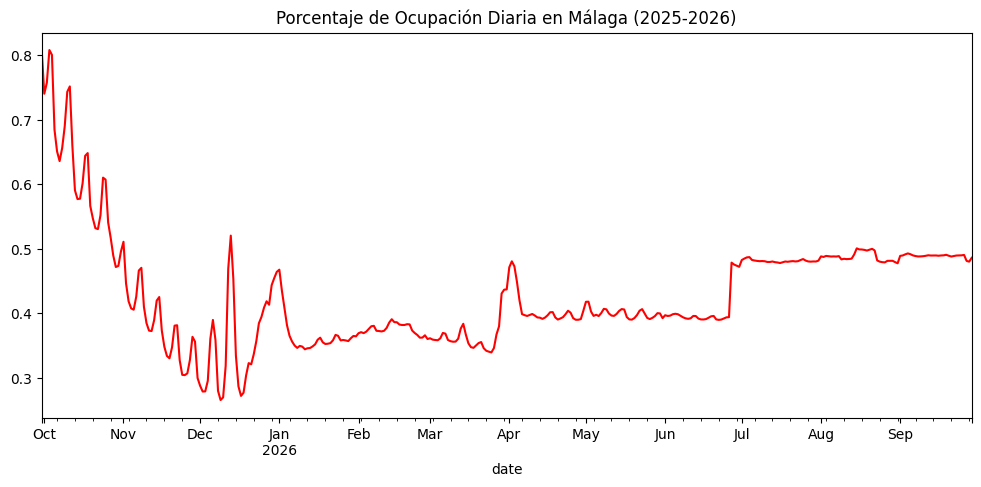

In [62]:
# Vamos a visualizar la ocupación media
calendar.groupby('date')['is_booked'].mean().plot(figsize=(12,5), color='red')
plt.title('Porcentaje de Ocupación Diaria en Málaga (2025-2026)')
plt.show()

Visualizamos si el número mínimo de noches es constante durante todo el año o si hay ciertos periodos donde se aumenta.

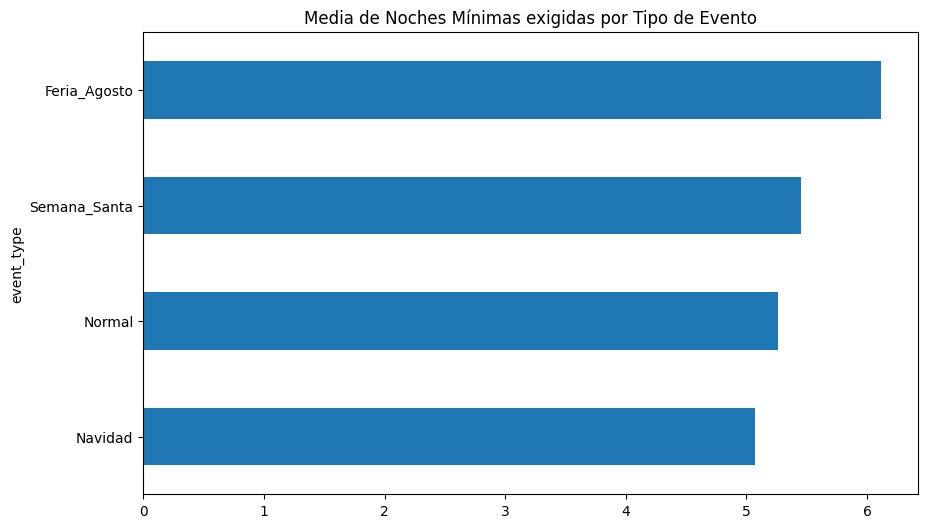

In [63]:
plt.figure(figsize=(10,6))
calendar.groupby('event_type')['minimum_nights'].mean().sort_values().plot(kind='barh')
plt.title('Media de Noches Mínimas exigidas por Tipo de Evento')
plt.show()

Como se puede ver en el gráfico, a dependiendo del tipo de evento que hay, el número medio de noches mínimas exigidas para reservar el airbnb puede aumentar o disminuir.